# Análise integrada — cenário de custo fixo "Custo Operacional (CONAB)"

Este notebook repete a análise integrada do `10_analise_integrada.ipynb` (risco climático via ISNA
+ produtividade prevista pelo ExtraTrees + viabilidade econômica), mas usando **só o cenário de
custo fixo "Custo Operacional (CONAB)"** construído no `09b_analise_custo_modelos.ipynb` — o que
desconta especificamente a Renda de Fatores (medida ano a ano a partir da série CONAB), em vez do
custo fixo inteiro sob uma fração de rateio assumida (100%/50%/proporcional).

**Diferente do `10`, este notebook não compara entre cenários de custo fixo** — usa só o cenário
Operacional (CONAB) do início ao fim, sem as colunas/seções de sensibilidade ao rateio que o `10`
tem na seção 6.1 (ali fazia sentido comparar 3 cenários; aqui há só um).

Mesma estrutura do `10`: soma ordinal de tercis (seções 1-4) e depois PCA + TOPSIS (seções 5-6) pra
resolver a redundância entre ISNA e produtividade prevista (ambos capturam boa parte do mesmo sinal
hídrico — ver seção 2).

**Não resimula clima nem produtividade** — reaproveita `previsoes_oeste_pr.csv` e
`risco_climatico_oeste_pr.csv` (exportados pelo `09`) e `risco_economico_oeste_pr_operacional_conab.csv`
(exportado pelo `09b`). Se o `09` ou o `09b` forem reexecutados com dados novos, reexecute este
notebook em seguida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

previsoes = pd.read_csv("previsoes_oeste_pr.csv")
risco_climatico = pd.read_csv("risco_climatico_oeste_pr.csv")
risco_economico = pd.read_csv("risco_economico_oeste_pr_operacional_conab.csv")

SEM = ["05/02/", "15/02/", "25/02/", "05/03/", "15/03/", "25/03/"]

print(previsoes.shape, risco_climatico.shape, risco_economico.shape)
previsoes.head(3)

(8100, 4) (300, 12) (300, 6)


,municipio,ano,data_semeadura,produtividade_prevista_kg_ha
0,Anahy,1999,05/02/,3412.300240
1,Anahy,1999,15/02/,3478.131683
2,Anahy,1999,25/02/,3452.163850


## 1. Novo eixo — produtividade prevista (ExtraTrees)

Para cada (município, data de semeadura), calculamos a média e o desvio-padrão da
`produtividade_prevista_kg_ha` nos 27 anos simulados (1999-2025, mesma base do eixo climático).
Classificamos em **tercis**, mesma escala ordinal 0/1/2 usada nos outros dois eixos.

In [2]:
produtividade_cidade_data = (
    previsoes.groupby(["municipio", "data_semeadura"])["produtividade_prevista_kg_ha"]
    .agg(produtividade_media_kg_ha="mean", produtividade_desvio_kg_ha="std", n_anos="count")
    .reset_index()
)

produtividade_cidade_data["classe_produtividade"] = pd.qcut(
    produtividade_cidade_data["produtividade_media_kg_ha"],
    q=3,
    labels=["Baixa produtividade prevista", "Produtividade prevista intermediária", "Alta produtividade prevista"],
).astype(str)

print(produtividade_cidade_data["classe_produtividade"].value_counts())
produtividade_cidade_data.sort_values("produtividade_media_kg_ha", ascending=False).head(15)

classe_produtividade
Alta produtividade prevista             100
Produtividade prevista intermediária    100
Baixa produtividade prevista            100
Name: count, dtype: int64


,municipio,data_semeadura,produtividade_media_kg_ha,produtividade_desvio_kg_ha,n_anos,classe_produtividade
74,Diamante do Sul,15/02/,3436.361728,327.450791,27,Alta produtividade prevista
50,Catanduvas,15/02/,3427.019118,377.482541,27,Alta produtividade prevista
98,Guaraniaçu,15/02/,3425.488127,379.607297,27,Alta produtividade prevista
52,Catanduvas,25/02/,3414.119400,369.493402,27,Alta produtividade prevista
110,Ibema,15/02/,3413.927184,387.865613,27,Alta produtividade prevista
112,Ibema,25/02/,3410.841034,377.328282,27,Alta produtividade prevista
46,Cascavel,25/02/,3405.620391,382.045053,27,Alta produtividade prevista
100,Guaraniaçu,25/02/,3404.090515,378.112842,27,Alta produtividade prevista
72,Diamante do Sul,05/02/,3402.397197,261.132343,27,Alta produtividade prevista
32,Campo Bonito,15/02/,3401.668453,381.093760,27,Alta produtividade prevista


## 2. ISNA × produtividade prevista — os dois eixos são redundantes?

Mesma checagem do `10` — não muda com o cenário de custo, já que não envolve a parte econômica.

Pearson r = 0.849 (p=1.2e-84)
Spearman rho = 0.856 (p=1.9e-87)


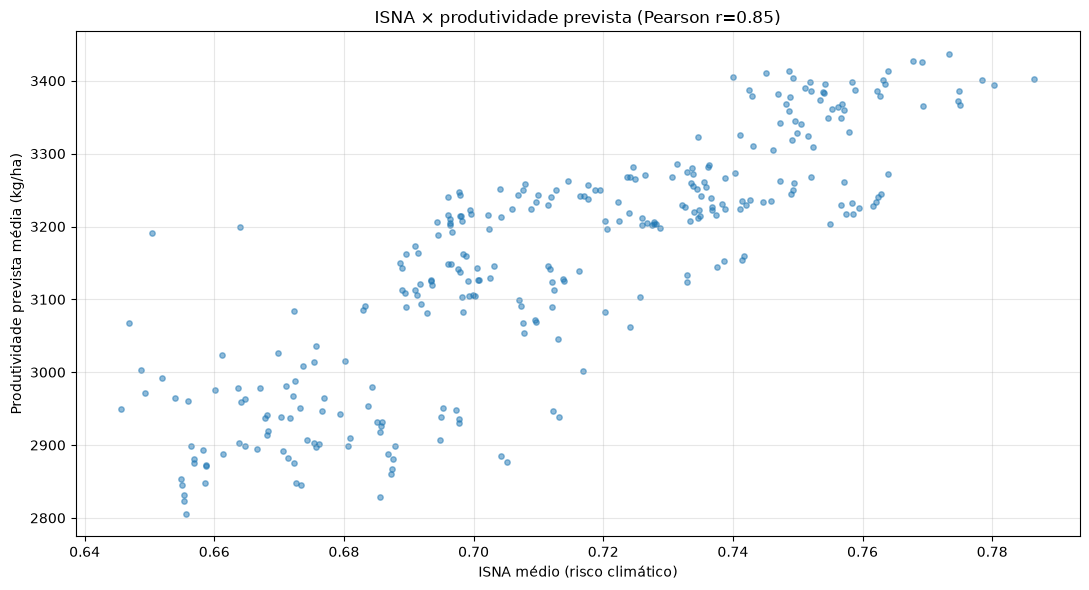

In [3]:
comparacao_isna_produtividade = risco_climatico[["municipio", "data_semeadura", "isna_medio"]].merge(
    produtividade_cidade_data[["municipio", "data_semeadura", "produtividade_media_kg_ha"]],
    on=["municipio", "data_semeadura"],
)

r_pearson, p_pearson = stats.pearsonr(
    comparacao_isna_produtividade["isna_medio"], comparacao_isna_produtividade["produtividade_media_kg_ha"]
)
r_spearman, p_spearman = stats.spearmanr(
    comparacao_isna_produtividade["isna_medio"], comparacao_isna_produtividade["produtividade_media_kg_ha"]
)
print(f"Pearson r = {r_pearson:.3f} (p={p_pearson:.1e})")
print(f"Spearman rho = {r_spearman:.3f} (p={p_spearman:.1e})")

fig, ax = plt.subplots()
ax.scatter(
    comparacao_isna_produtividade["isna_medio"],
    comparacao_isna_produtividade["produtividade_media_kg_ha"],
    alpha=0.5, s=15,
)
ax.set_xlabel("ISNA médio (risco climático)")
ax.set_ylabel("Produtividade prevista média (kg/ha)")
ax.set_title(f"ISNA × produtividade prevista (Pearson r={r_pearson:.2f})")
plt.tight_layout()
plt.show()

Correlação forte (Pearson r ≈ 0,85) — os dois eixos carregam boa parte da mesma informação
hídrica, mas não são idênticos. O `score_integrado` da seção 3 pondera esse componente duas vezes;
a PCA da seção 5 resolve isso.

## 3. Matriz integrada — três eixos combinados (cenário Operacional CONAB)

Une os três eixos numa única tabela, escala ordinal 0 (melhor) a 2/3 (pior) por eixo, somando num
`score_integrado` (0 = melhor nos três eixos, 7 = pior — 4 níveis de risco climático + 2 de
produtividade + 2 de econômico).

In [4]:
matriz_integrada = (
    risco_climatico
    .merge(produtividade_cidade_data.drop(columns="n_anos"), on=["municipio", "data_semeadura"])
    .merge(
        risco_economico[["municipio", "data_semeadura", "pct_anos_cobre_custo", "margem_media_rs_ha", "risco_economico"]],
        on=["municipio", "data_semeadura"],
    )
)

ORDEM_CLIMA = {"Risco climático 20%": 0, "Risco climático 30%": 1, "Risco climático 40%": 2, "Inapto (risco > 40%)": 3}
ORDEM_PRODUTIVIDADE = {
    "Alta produtividade prevista": 0,
    "Produtividade prevista intermediária": 1,
    "Baixa produtividade prevista": 2,
}
ORDEM_ECONOMICO = {"Mais viável": 0, "Viabilidade intermediária": 1, "Menos viável": 2}

matriz_integrada["score_clima"] = matriz_integrada["risco_climatico"].map(ORDEM_CLIMA).astype(int)
matriz_integrada["score_produtividade"] = matriz_integrada["classe_produtividade"].map(ORDEM_PRODUTIVIDADE).astype(int)
matriz_integrada["score_economico"] = matriz_integrada["risco_economico"].map(ORDEM_ECONOMICO).astype(int)
matriz_integrada["score_integrado"] = (
    matriz_integrada["score_clima"] + matriz_integrada["score_produtividade"] + matriz_integrada["score_economico"]
)

matriz_integrada.to_csv("matriz_integrada_oeste_pr_operacional_conab.csv", index=False, encoding="utf-8-sig")

print("Distribuição do score integrado (0=melhor, 7=pior):")
print(matriz_integrada["score_integrado"].value_counts().sort_index())
matriz_integrada.sort_values("score_integrado").head(10)

Distribuição do score integrado (0=melhor, 7=pior):
score_integrado
1    30
2    38
3    47
4    24
5    63
6    20
7    78
Name: count, dtype: int64


,municipio,data_semeadura,isna_medio,isna_desvio,n_anos,freq_evento_adverso,freq_deficit_faseI,freq_deficit_faseIII,freq_frio_floracao,freq_geada,...,produtividade_media_kg_ha,produtividade_desvio_kg_ha,classe_produtividade,pct_anos_cobre_custo,margem_media_rs_ha,risco_economico,score_clima,score_produtividade,score_economico,score_integrado
40,Capitão Leônidas Marques,25/02/,0.732853,0.092913,27,0.259259,0.222222,0.111111,0.962963,0.000000,...,3274.123133,495.596453,Alta produtividade prevista,46.2,78.424361,Mais viável,1,0,0,1
44,Cascavel,15/02/,0.758423,0.091020,27,0.296296,0.037037,0.259259,0.851852,0.000000,...,3398.249201,397.010868,Alta produtividade prevista,50.0,91.015657,Mais viável,1,0,0,1
34,Campo Bonito,25/02/,0.742515,0.097601,27,0.296296,0.148148,0.185185,0.962963,0.000000,...,3387.481627,373.463401,Alta produtividade prevista,50.0,100.173011,Mais viável,1,0,0,1
46,Cascavel,25/02/,0.740043,0.095847,27,0.259259,0.148148,0.148148,0.962963,0.000000,...,3405.620391,382.045053,Alta produtividade prevista,50.0,104.052241,Mais viável,1,0,0,1
32,Campo Bonito,15/02/,0.763090,0.092860,27,0.296296,0.037037,0.259259,0.851852,0.000000,...,3401.668453,381.093760,Alta produtividade prevista,50.0,91.868764,Mais viável,1,0,0,1
73,Diamante do Sul,05/03/,0.751985,0.106249,27,0.296296,0.185185,0.111111,1.000000,0.037037,...,3386.323564,341.005653,Alta produtividade prevista,50.0,98.362015,Mais viável,1,0,0,1
52,Catanduvas,25/02/,0.748630,0.096339,27,0.259259,0.148148,0.148148,0.962963,0.000000,...,3414.119400,369.493402,Alta produtividade prevista,50.0,106.973281,Mais viável,1,0,0,1
50,Catanduvas,15/02/,0.767835,0.091323,27,0.296296,0.037037,0.259259,0.851852,0.000000,...,3427.019118,377.482541,Alta produtividade prevista,50.0,99.518443,Mais viável,1,0,0,1
282,Três Barras do Paraná,05/02/,0.763884,0.103987,27,0.296296,0.222222,0.111111,0.555556,0.000000,...,3271.805642,352.127181,Alta produtividade prevista,50.0,58.245429,Mais viável,1,0,0,1
64,Céu Azul,25/02/,0.723693,0.098315,27,0.296296,0.222222,0.148148,0.962963,0.000000,...,3267.296940,464.297023,Alta produtividade prevista,50.0,72.473022,Mais viável,1,0,0,1


## 4. Melhor data de semeadura por município

Menor `score_integrado`, com desempate pela maior produtividade prevista.

In [5]:
melhor_data_integrada = (
    matriz_integrada
    .sort_values(["municipio", "score_integrado", "produtividade_media_kg_ha"], ascending=[True, True, False])
    .groupby("municipio")
    .first()
    .reset_index()[[
        "municipio", "data_semeadura", "risco_climatico", "classe_produtividade", "risco_economico",
        "produtividade_media_kg_ha", "margem_media_rs_ha", "score_integrado",
    ]]
)
melhor_data_integrada.to_csv("melhor_data_semeadura_integrada_operacional_conab.csv", index=False, encoding="utf-8-sig")
melhor_data_integrada.sort_values("score_integrado")

,municipio,data_semeadura,risco_climatico,classe_produtividade,risco_economico,produtividade_media_kg_ha,margem_media_rs_ha,score_integrado
3,Braganey,15/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3395.729346,90.318393,1
2,Boa Vista da Aparecida,15/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3341.900707,92.293262,1
6,Capitão Leônidas Marques,25/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3274.123133,78.424361,1
5,Campo Bonito,15/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3401.668453,91.868764,1
7,Cascavel,25/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3405.620391,104.052241,1
12,Diamante do Sul,15/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3436.361728,104.339435,1
10,Céu Azul,25/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3267.296940,72.473022,1
8,Catanduvas,15/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3427.019118,99.518443,1
26,Matelândia,25/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3279.695689,78.763435,1
23,Lindoeste,25/02/,Risco climático 30%,Alta produtividade prevista,Mais viável,3284.679980,80.478675,1


### Mapa de calor — score integrado por município × data de semeadura

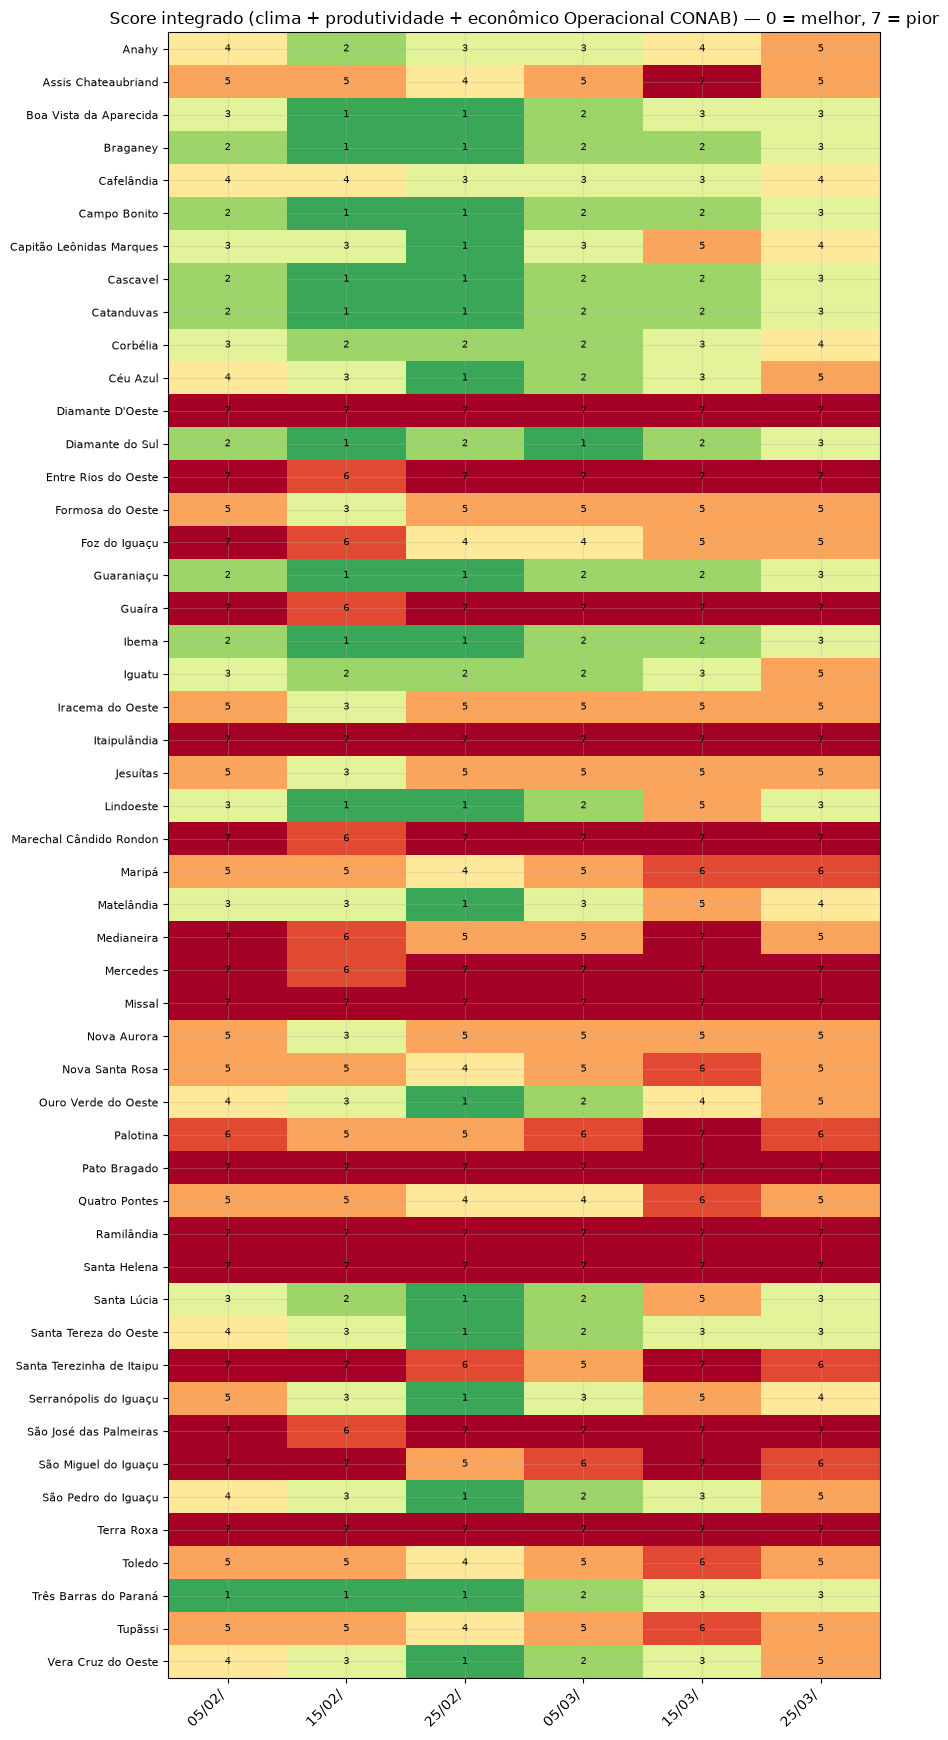

In [6]:
pivot_score_integrado = matriz_integrada.pivot(index="municipio", columns="data_semeadura", values="score_integrado")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_score_integrado))))
im = ax.imshow(pivot_score_integrado, cmap="RdYlGn_r", vmin=0, vmax=7, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_score_integrado.index)))
ax.set_yticklabels(pivot_score_integrado.index, fontsize=8)
for i in range(pivot_score_integrado.shape[0]):
    for j in range(pivot_score_integrado.shape[1]):
        v = pivot_score_integrado.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7)
ax.set_title("Score integrado (clima + produtividade + econômico Operacional CONAB) — 0 = melhor, 7 = pior")
plt.tight_layout()
plt.show()

## 5. PCA — componente agroclimático (clima + produtividade)

Mesma lógica do `10`: a soma ordinal pondera o componente hídrico duas vezes (ISNA e produtividade
prevista correlacionados, seção 2). PCA sobre as duas variáveis padronizadas extrai um único eixo
agroclimático, sem essa redundância.

In [7]:
X_clima_produtividade = StandardScaler().fit_transform(
    matriz_integrada[["isna_medio", "produtividade_media_kg_ha"]].to_numpy()
)

pca = PCA(n_components=1)
componente_agroclimatico = pca.fit_transform(X_clima_produtividade).ravel()

if np.corrcoef(componente_agroclimatico, matriz_integrada["produtividade_media_kg_ha"])[0, 1] < 0:
    componente_agroclimatico = -componente_agroclimatico

matriz_integrada["componente_agroclimatico"] = componente_agroclimatico

print(f"Variância explicada pelo 1º componente: {pca.explained_variance_ratio_[0]:.1%}")
matriz_integrada[
    ["municipio", "data_semeadura", "isna_medio", "produtividade_media_kg_ha", "componente_agroclimatico"]
].sort_values("componente_agroclimatico", ascending=False).head(10)

Variância explicada pelo 1º componente: 92.5%


,municipio,data_semeadura,isna_medio,produtividade_media_kg_ha,componente_agroclimatico
72,Diamante do Sul,05/02/,0.786501,3402.397197,2.658725
74,Diamante do Sul,15/02/,0.773392,3436.361728,2.528973
96,Guaraniaçu,05/02/,0.780250,3394.477472,2.491726
48,Catanduvas,05/02/,0.778491,3400.938955,2.482621
98,Guaraniaçu,15/02/,0.769103,3425.488127,2.390674
50,Catanduvas,15/02/,0.767835,3427.019118,2.370485
108,Ibema,05/02/,0.774810,3386.472571,2.341539
30,Campo Bonito,05/02/,0.774672,3372.283423,2.276760
18,Braganey,05/02/,0.775017,3366.104875,2.257129
110,Ibema,15/02/,0.763993,3413.927184,2.231988


## 6. TOPSIS — ranking do risco integrado (agroclimático × econômico Operacional CONAB)

TOPSIS sobre dois critérios "quanto maior, melhor": `componente_agroclimatico` (PCA) e
`margem_media_rs_ha` (margem do cenário Operacional CONAB, contínua — não o tercil de
`risco_economico`). Pesos 50/50, mesma lógica do `10`.

In [8]:
def calcular_topsis(matriz, coluna_margem, pesos=np.array([0.5, 0.5])):
    criterios = matriz[["componente_agroclimatico", coluna_margem]].to_numpy()
    norm = criterios / np.sqrt((criterios ** 2).sum(axis=0))
    matriz_pesada = norm * pesos

    solucao_ideal = matriz_pesada.max(axis=0)
    solucao_anti_ideal = matriz_pesada.min(axis=0)

    dist_ideal = np.sqrt(((matriz_pesada - solucao_ideal) ** 2).sum(axis=1))
    dist_anti_ideal = np.sqrt(((matriz_pesada - solucao_anti_ideal) ** 2).sum(axis=1))
    return dist_anti_ideal / (dist_ideal + dist_anti_ideal)


pesos = np.array([0.5, 0.5])  # ajuste aqui se algum critério for considerado mais importante

matriz_integrada["topsis_score"] = calcular_topsis(matriz_integrada, "margem_media_rs_ha", pesos)
matriz_integrada["classe_risco_topsis"] = pd.qcut(
    matriz_integrada["topsis_score"], q=3,
    labels=["Alto risco integrado", "Risco integrado intermediário", "Baixo risco integrado"],
).astype(str)

matriz_integrada.to_csv("matriz_topsis_oeste_pr_operacional_conab.csv", index=False, encoding="utf-8-sig")

print(matriz_integrada["classe_risco_topsis"].value_counts())
matriz_integrada.sort_values("topsis_score", ascending=False)[
    ["municipio", "data_semeadura", "componente_agroclimatico", "margem_media_rs_ha", "topsis_score", "classe_risco_topsis"]
].head(10)

classe_risco_topsis
Baixo risco integrado            100
Risco integrado intermediário    100
Alto risco integrado             100
Name: count, dtype: int64


,municipio,data_semeadura,componente_agroclimatico,margem_media_rs_ha,topsis_score,classe_risco_topsis
74,Diamante do Sul,15/02/,2.528973,104.339435,0.978930,Baixo risco integrado
72,Diamante do Sul,05/02/,2.658725,93.778737,0.953750,Baixo risco integrado
98,Guaraniaçu,15/02/,2.390674,99.055416,0.951856,Baixo risco integrado
50,Catanduvas,15/02/,2.370485,99.518443,0.950368,Baixo risco integrado
48,Catanduvas,05/02/,2.482621,90.942236,0.937767,Baixo risco integrado
96,Guaraniaçu,05/02/,2.491726,88.756797,0.931310,Baixo risco integrado
110,Ibema,15/02/,2.231988,95.984141,0.926624,Baixo risco integrado
108,Ibema,05/02/,2.341539,85.786688,0.911931,Baixo risco integrado
32,Campo Bonito,15/02/,2.159401,91.868764,0.909568,Baixo risco integrado
51,Catanduvas,15/03/,2.070121,96.628417,0.907122,Baixo risco integrado


### Melhor data de semeadura por município — via TOPSIS

Maior `topsis_score` por município (score contínuo, sem necessidade de desempate).

In [9]:
melhor_data_topsis = (
    matriz_integrada.sort_values(["municipio", "topsis_score"], ascending=[True, False])
    .groupby("municipio")
    .first()
    .reset_index()[[
        "municipio", "data_semeadura", "componente_agroclimatico", "margem_media_rs_ha",
        "topsis_score", "classe_risco_topsis",
    ]]
)
melhor_data_topsis.to_csv("melhor_data_semeadura_topsis_operacional_conab.csv", index=False, encoding="utf-8-sig")
melhor_data_topsis.sort_values("topsis_score", ascending=False).head(10)

,municipio,data_semeadura,componente_agroclimatico,margem_media_rs_ha,topsis_score,classe_risco_topsis
12,Diamante do Sul,15/02/,2.528973,104.339435,0.978930,Baixo risco integrado
16,Guaraniaçu,15/02/,2.390674,99.055416,0.951856,Baixo risco integrado
8,Catanduvas,15/02/,2.370485,99.518443,0.950368,Baixo risco integrado
18,Ibema,15/02/,2.231988,95.984141,0.926624,Baixo risco integrado
5,Campo Bonito,15/02/,2.159401,91.868764,0.909568,Baixo risco integrado
3,Braganey,15/02/,2.140578,90.318393,0.904025,Baixo risco integrado
7,Cascavel,15/02/,2.045589,91.015657,0.894270,Baixo risco integrado
47,Três Barras do Paraná,15/02/,1.751950,91.983954,0.858670,Baixo risco integrado
2,Boa Vista da Aparecida,15/02/,1.562937,92.293262,0.834349,Baixo risco integrado
23,Lindoeste,25/03/,1.473332,66.875433,0.775961,Baixo risco integrado


### Mapa de calor — score TOPSIS por município × data de semeadura

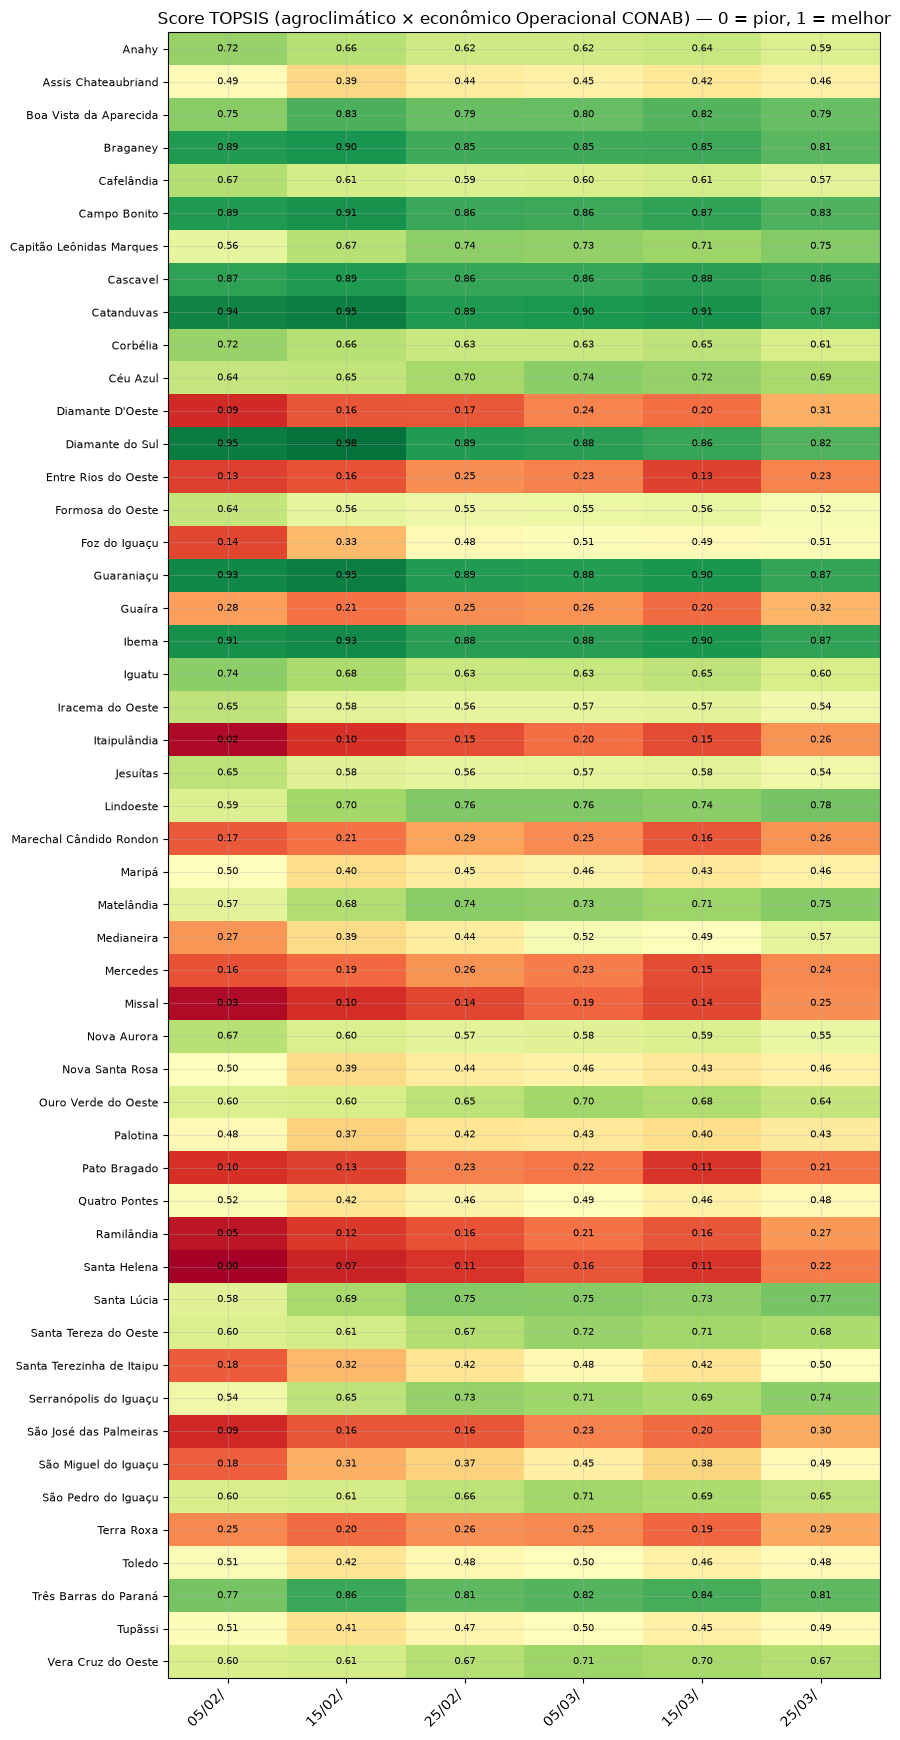

In [10]:
pivot_topsis = matriz_integrada.pivot(index="municipio", columns="data_semeadura", values="topsis_score")[SEM]

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(pivot_topsis))))
im = ax.imshow(pivot_topsis, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(SEM)))
ax.set_xticklabels(SEM, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_topsis.index)))
ax.set_yticklabels(pivot_topsis.index, fontsize=8)
for i in range(pivot_topsis.shape[0]):
    for j in range(pivot_topsis.shape[1]):
        v = pivot_topsis.iloc[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Score TOPSIS (agroclimático × econômico Operacional CONAB) — 0 = pior, 1 = melhor")
plt.tight_layout()
plt.show()

## 7. Limitações a considerar

**Sobre a soma ordinal de tercis (seção 3):**
- Pondera o componente hídrico duas vezes (ISNA e produtividade prevista têm correlação de 0,85) —
  é o problema que a PCA da seção 5 resolve.
- Tercis por eixo perdem magnitude e geram empates frequentes de `score_integrado`.

**Sobre PCA + TOPSIS (seções 5-6):**
- Pesos 50/50 entre componente agroclimático e margem econômica são uma escolha arbitrária,
  ajustáveis no vetor `pesos`.
- PCA assume relação linear entre ISNA e produtividade prevista — a correlação de Pearson (≈0,85)
  sustenta essa suposição aqui, mas não é validada formalmente.
- Produtividade prevista usa 27 anos (1999-2025); margem econômica usa 26 anos (1999-2024, limitado
  pela série DERAL) — os dois critérios do TOPSIS não compartilham exatamente a mesma janela
  temporal.
- Tercis de `classe_risco_topsis` são relativos ao próprio cenário simulado (300 combinações), não
  um corte absoluto.

**Específicas deste notebook (herdadas do `09b`):**
- O cenário econômico usa a proporção de Renda de Fatores medida no pacote **CONAB "Alta
  Tecnologia"**, aplicada sobre o custo absoluto **DERAL "Milho Safrinha"** — os dois pacotes têm
  produtividade de referência diferente (~104 sc/ha vs. ~60-80 sc/ha), o que pode subestimar
  levemente a proporção real do pacote DERAL (ver `09b`, seção 8).
- Este notebook **não compara** com os cenários 100%/50%/proporcional (diferente do `10`, seção
  6.1) — para essa comparação, ver o `10` original ou o `09b`, seção 5.
- Depende dos CSVs exportados pelo `09` e pelo `09b` — se algum dos dois for reexecutado com dados
  novos, reexecute este notebook em seguida.